# Interim Results Figures

This notebook generates publication-ready figures for the interim Results section using existing artifacts (no retraining required).
Run cells top-to-bottom. Each figure cell saves output to `docs/figures/` and displays it inline.


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
FIG_DIR = os.path.join(PROJECT_ROOT, 'docs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

BASE_METRICS = os.path.join(PROJECT_ROOT, 'experiments', 'pcam_baseline', 'metrics.json')
BASE_LOG = os.path.join(PROJECT_ROOT, 'experiments', 'pcam_baseline', 'training_log.csv')
BASE_CM_PNG = os.path.join(PROJECT_ROOT, 'experiments', 'pcam_baseline', 'confusion_matrices.png')
REP_TRIAL1 = os.path.join(PROJECT_ROOT, 'pcam_data', 'preprocessed', 'preprocess_report.json')
REP_TRIAL2 = os.path.join(PROJECT_ROOT, 'pcam_data', 'preprocessed_multi_ref', 'preprocess_report.json')
QA_TRIAL2_TRAIN = os.path.join(PROJECT_ROOT, 'pcam_data', 'preprocessed_multi_ref', 'train_qa_samples.npz')

for p in [BASE_METRICS, BASE_LOG, BASE_CM_PNG, REP_TRIAL1, REP_TRIAL2, QA_TRIAL2_TRAIN]:
    print(('OK   ' if os.path.isfile(p) else 'MISS '), p)
print('Figure output dir:', FIG_DIR)


OK    c:\GP_ECG\experiments\pcam_baseline\metrics.json
OK    c:\GP_ECG\experiments\pcam_baseline\training_log.csv
OK    c:\GP_ECG\experiments\pcam_baseline\confusion_matrices.png
OK    c:\GP_ECG\pcam_data\preprocessed\preprocess_report.json
OK    c:\GP_ECG\pcam_data\preprocessed_multi_ref\preprocess_report.json
OK    c:\GP_ECG\pcam_data\preprocessed_multi_ref\train_qa_samples.npz
Figure output dir: c:\GP_ECG\docs\figures


## Figure 1 - Data curation impact (Results: preprocessing outcomes)

Insert this figure in the preprocessing-results subsection to show retention by split and the reasons for removed patches.


Saved: c:\GP_ECG\docs\figures\fig1_data_curation.png


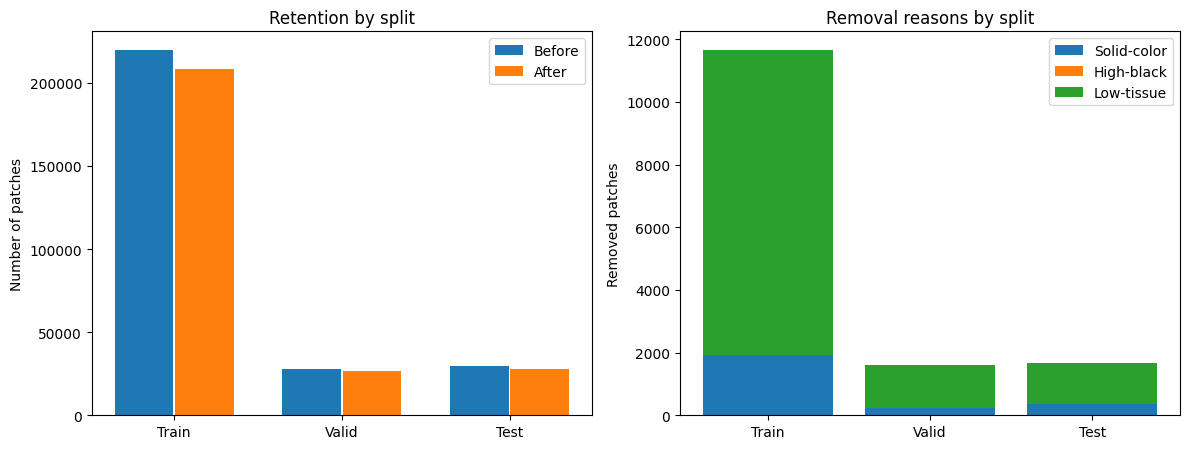

In [2]:
with open(REP_TRIAL1, 'r', encoding='utf-8') as f:
    rep = json.load(f)

splits = ['train', 'valid', 'test']
before = [rep['per_split'][s]['n_before'] for s in splits]
after = [rep['per_split'][s]['n_after'] for s in splits]
solid = [rep['per_split'][s]['step1_removed']['solid_color'] for s in splits]
black = [rep['per_split'][s]['step1_removed']['high_black'] for s in splits]
low_tissue = [rep['per_split'][s]['step1_removed']['low_tissue'] for s in splits]

x = np.arange(len(splits))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].bar(x - 0.18, before, width=0.35, label='Before')
axes[0].bar(x + 0.18, after, width=0.35, label='After')
axes[0].set_xticks(x); axes[0].set_xticklabels([s.title() for s in splits])
axes[0].set_ylabel('Number of patches'); axes[0].set_title('Retention by split'); axes[0].legend()

axes[1].bar(x, solid, label='Solid-color')
axes[1].bar(x, black, bottom=solid, label='High-black')
axes[1].bar(x, low_tissue, bottom=np.array(solid) + np.array(black), label='Low-tissue')
axes[1].set_xticks(x); axes[1].set_xticklabels([s.title() for s in splits])
axes[1].set_ylabel('Removed patches'); axes[1].set_title('Removal reasons by split'); axes[1].legend()

plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig1_data_curation.png')
plt.savefig(out, dpi=220, bbox_inches='tight')
print('Saved:', out)
plt.show()


## Figure 2 - Baseline confusion matrices (Results: baseline model performance)

Insert this as the main baseline classification visualization.


Saved: c:\GP_ECG\docs\figures\fig2_baseline_confusion_matrices.png


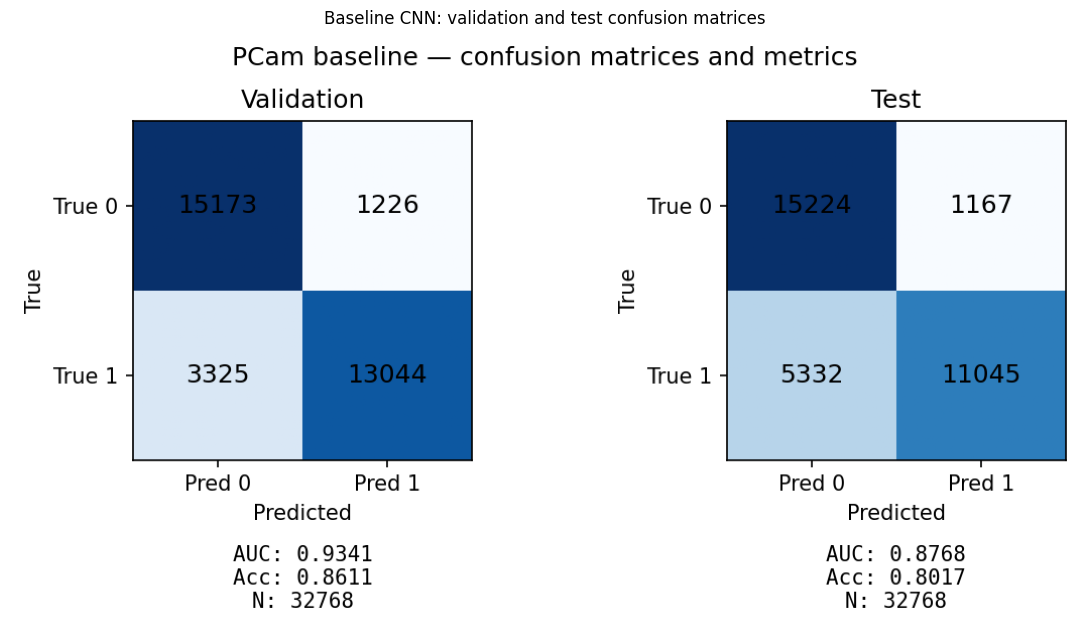

In [3]:
img = imread(BASE_CM_PNG)
plt.figure(figsize=(11, 6.5))
plt.imshow(img)
plt.axis('off')
plt.title('Baseline CNN: validation and test confusion matrices')
plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig2_baseline_confusion_matrices.png')
plt.savefig(out, dpi=220, bbox_inches='tight')
print('Saved:', out)
plt.show()


## Figure 3 - Baseline training dynamics (Results: optimization behavior)

Insert this where you discuss convergence and overfitting behavior across epochs.


Saved: c:\GP_ECG\docs\figures\fig3_baseline_training_curves.png


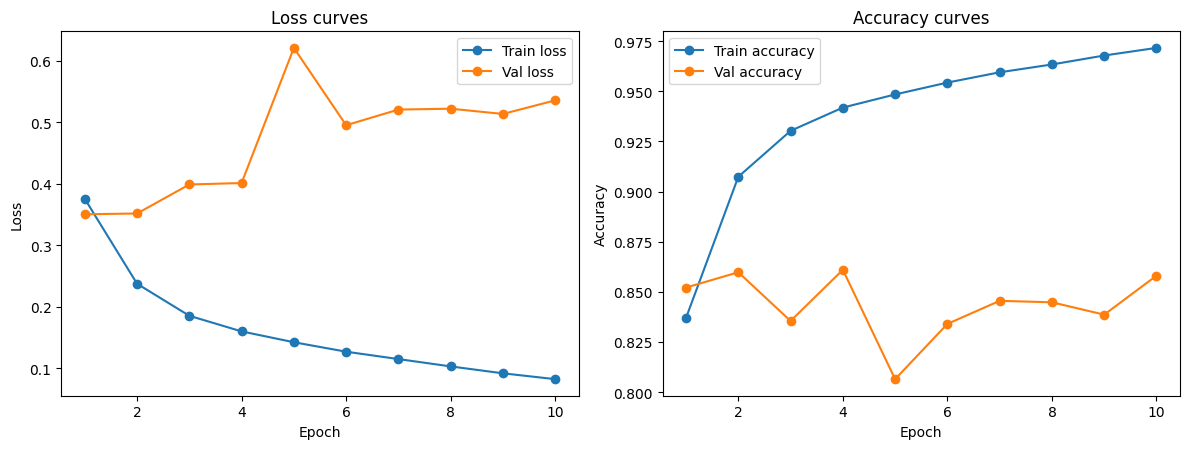

In [4]:
log = pd.read_csv(BASE_LOG)
epochs = log['epoch'].values + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(epochs, log['loss'], marker='o', label='Train loss')
axes[0].plot(epochs, log['val_loss'], marker='o', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss curves'); axes[0].legend()

axes[1].plot(epochs, log['accuracy'], marker='o', label='Train accuracy')
axes[1].plot(epochs, log['val_accuracy'], marker='o', label='Val accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy curves'); axes[1].legend()

plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig3_baseline_training_curves.png')
plt.savefig(out, dpi=220, bbox_inches='tight')
print('Saved:', out)
plt.show()


## Figure 4 - Trial 1 vs Trial 2 stain metrics (Results: stain trial comparison)

Insert this in the section comparing stain-normalization trials on matched sampled patches.


Saved: c:\GP_ECG\docs\figures\fig4_trial1_vs_trial2_stain_metrics.png
Paired same-index mean L1 shift (Trial 1 vs Trial 2): 0.2413


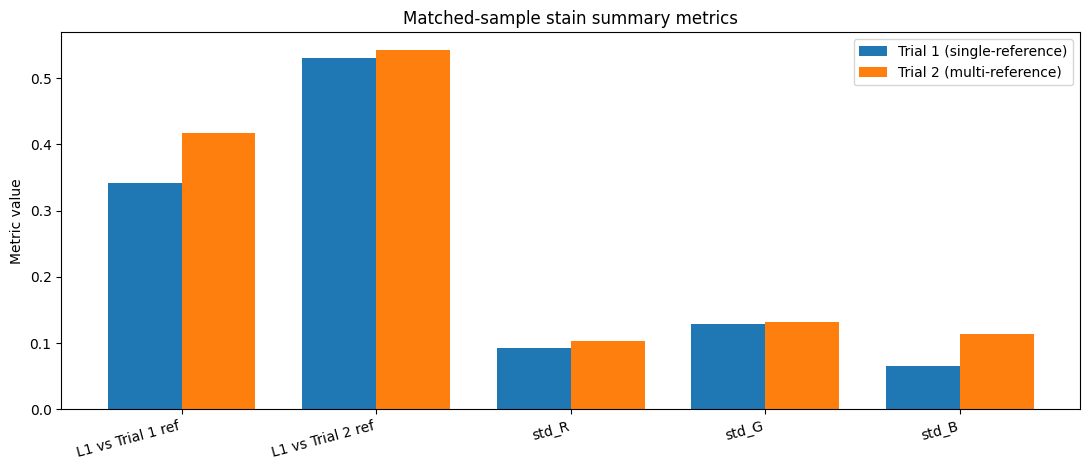

In [5]:
# From matched-sample comparison run (train split, 3000 sampled patches)
metrics = {
    'L1 vs Trial 1 ref': (0.3413, 0.4178),
    'L1 vs Trial 2 ref': (0.5302, 0.5422),
    'std_R': (0.0925, 0.1035),
    'std_G': (0.1285, 0.1324),
    'std_B': (0.0658, 0.1134),
}
labels = list(metrics.keys())
trial1 = [metrics[k][0] for k in labels]
trial2 = [metrics[k][1] for k in labels]

x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(11, 4.8))
plt.bar(x - w/2, trial1, width=w, label='Trial 1 (single-reference)')
plt.bar(x + w/2, trial2, width=w, label='Trial 2 (multi-reference)')
plt.xticks(x, labels, rotation=15, ha='right')
plt.ylabel('Metric value')
plt.title('Matched-sample stain summary metrics')
plt.legend()
plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig4_trial1_vs_trial2_stain_metrics.png')
plt.savefig(out, dpi=220, bbox_inches='tight')
print('Saved:', out)
print('Paired same-index mean L1 shift (Trial 1 vs Trial 2): 0.2413')
plt.show()


## Figure 5 - Trial 2 normalization pathway composition (Results: Trial 2 stain behavior)

Insert this where you describe how frequently each normalization path was used in Trial 2.


Saved: c:\GP_ECG\docs\figures\fig5_trial2_normalizer_usage.png


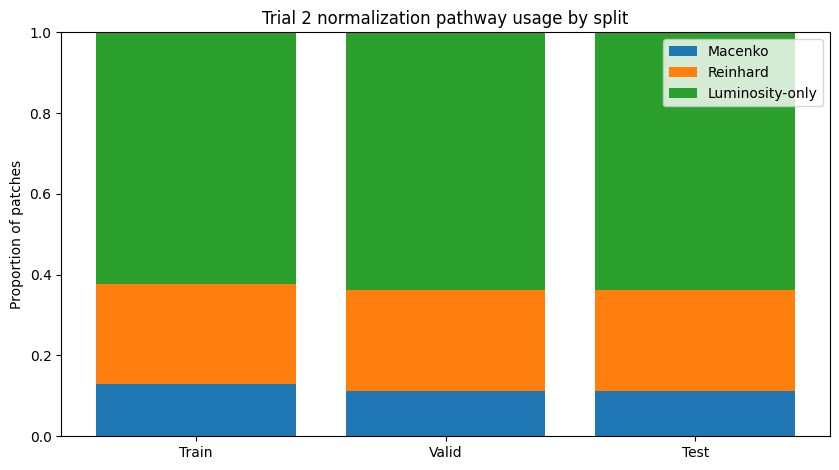

In [6]:
with open(REP_TRIAL2, 'r', encoding='utf-8') as f:
    rep2 = json.load(f)

splits = ['train', 'valid', 'test']
cats = ['macenko_rate', 'reinhard_rate', 'luminosity_only_rate']
cat_names = ['Macenko', 'Reinhard', 'Luminosity-only']
vals = np.array([[rep2['per_split'][s]['step2_normalizer_usage'][c] for c in cats] for s in splits])

x = np.arange(len(splits)); bottom = np.zeros(len(splits))
plt.figure(figsize=(8.5, 4.8))
for j, name in enumerate(cat_names):
    plt.bar(x, vals[:, j], bottom=bottom, label=name)
    bottom += vals[:, j]

plt.xticks(x, [s.title() for s in splits])
plt.ylim(0, 1.0)
plt.ylabel('Proportion of patches')
plt.title('Trial 2 normalization pathway usage by split')
plt.legend()
plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig5_trial2_normalizer_usage.png')
plt.savefig(out, dpi=220, bbox_inches='tight')
print('Saved:', out)
plt.show()


## Figure 6 - Qualitative QA montage (Results: qualitative stain assessment)

Insert this in a qualitative subsection to show representative before/after examples from Trial 2.


Saved: c:\GP_ECG\docs\figures\fig6_trial2_qa_montage_grouped.png
Selected indices by group: {'mac': [49, 24], 'rei': [52, 51], 'lum': [44, 35]}


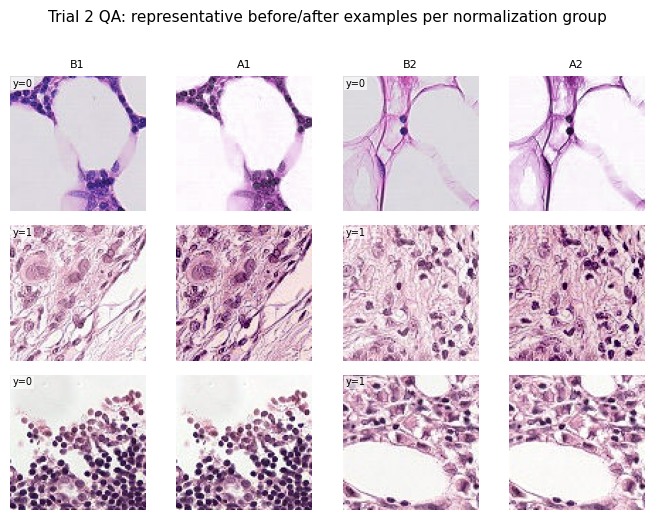

In [4]:
qa = np.load(QA_TRIAL2_TRAIN, allow_pickle=False)
orig = qa['original_u8']
norm = qa['normalized_u8']
codes = qa['normalizer_used']
labels = qa['labels']
name = {0:'mac', 1:'rei', 2:'mac_fb', 3:'rei_fb', 4:'lum'}

def pink_ratio(img_u8):
    img = img_u8.astype(np.float32)
    return float((img[:, :, 0] > img[:, :, 2]).mean())

def pick_representative_indices(group_idxs, k=2):
    candidates = []
    for i in group_idxs:
        pb = pink_ratio(orig[i])
        pa = pink_ratio(norm[i])
        drop = max(0.0, pb - pa)
        candidates.append((i, pb, pa, drop))

    # Strictly avoid severe pink->purple shifts when alternatives exist.
    strict = [x for x in candidates if (x[2] >= 0.15 and x[3] <= 0.25)]
    if len(strict) < k:
        strict = [x for x in candidates if (x[2] >= 0.10 and x[3] <= 0.35)]

    pool = strict if len(strict) >= k else candidates
    # Rank by smallest pink drop, then by larger after-pink.
    pool = sorted(pool, key=lambda x: (x[3], -x[2]))
    return [i for i, _, _, _ in pool[:k]]

# Show a couple of examples per normalization group, laid out horizontally.
K_PER_GROUP = 2
present_codes = [c for c in [0, 1, 2, 3, 4] if np.any(codes == c)]
rows = len(present_codes)
cols = 2 * K_PER_GROUP

fig, axes = plt.subplots(rows, cols, figsize=(1.7 * cols, 1.7 * rows))
if rows == 1:
    axes = np.expand_dims(axes, 0)

selected = {}
for r, c in enumerate(present_codes):
    group_idxs = np.where(codes == c)[0]
    idxs = pick_representative_indices(group_idxs, k=K_PER_GROUP)
    selected[c] = idxs
    for j in range(K_PER_GROUP):
        ax_b = axes[r, 2 * j]
        ax_a = axes[r, 2 * j + 1]
        if j < len(idxs):
            i = idxs[j]
            ax_b.imshow(orig[i])
            ax_a.imshow(norm[i])
            if r == 0:
                ax_b.set_title(f'B{j+1}', fontsize=8)
                ax_a.set_title(f'A{j+1}', fontsize=8)
            ax_b.text(0.02, 0.98, f'y={labels[i]:.0f}', transform=ax_b.transAxes,
                      va='top', ha='left', fontsize=7,
                      bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0))
        else:
            ax_b.axis('off')
            ax_a.axis('off')
            continue

        if j == 0:
            ax_b.set_ylabel(name[c], fontsize=9)

        ax_b.axis('off')
        ax_a.axis('off')

plt.suptitle('Trial 2 QA: representative before/after examples per normalization group', y=1.01, fontsize=11)
plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig6_trial2_qa_montage_grouped.png')
plt.savefig(out, dpi=260, bbox_inches='tight')
print('Saved:', out)
print('Selected indices by group:', {name[k]: v for k, v in selected.items()})
plt.show()


In [ ]:
## Figure 7 - Selected reference patches (Results: stain trial design)

Insert this where you explain the stain-normalization trial setup. It shows the single reference used in Trial 1 and the three fixed references used in Trial 2.

In [ ]:
import h5py

train_x_path = os.path.join(PROJECT_ROOT, 'pcam_data', 'training', 'camelyonpatch_level_2_split_train_x.h5')
with open(REP_TRIAL1, 'r', encoding='utf-8') as f:
    rep1 = json.load(f)
with open(REP_TRIAL2, 'r', encoding='utf-8') as f:
    rep2 = json.load(f)

idx_trial1 = int(rep1['config']['ref_train_idx'])
idx_trial2 = [int(x) for x in rep2['config']['multi_ref_indices']]
all_idxs = [idx_trial1] + idx_trial2

if not os.path.isfile(train_x_path):
    raise FileNotFoundError('Missing train_x.h5 at: ' + train_x_path)

imgs = []
with h5py.File(train_x_path, 'r') as f:
    x = f['x']
    for idx in all_idxs:
        p = np.array(x[idx])
        p01 = np.clip(p.astype(np.float32) / 255.0, 0, 1) if p.max() > 1 else np.clip(p.astype(np.float32), 0, 1)
        imgs.append(p01)

titles = [f'Trial 1 ref\nidx={idx_trial1}'] + [f'Trial 2 ref {j+1}\nidx={idx}' for j, idx in enumerate(idx_trial2)]

fig, axes = plt.subplots(1, len(imgs), figsize=(2.8 * len(imgs), 3.0))
if len(imgs) == 1:
    axes = [axes]

for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle('Reference patches used for stain normalization trials', y=1.02, fontsize=11)
plt.tight_layout()
out = os.path.join(FIG_DIR, 'fig7_stain_reference_patches.png')
plt.savefig(out, dpi=260, bbox_inches='tight')
print('Saved:', out)
plt.show()